# **AI Agent_Agentic RAG**

## **1.환경준비**

### (1) 구글 드라이브

#### 1) 구글 드라이브 폴더 생성
* 새 폴더(LangGraph)를 생성하고
* 제공 받은 파일을 업로드

#### 2) 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (2) 라이브러리

#### 1) 필요한 라이브러리 설치

In [ ]:
!pip install langchain langgraph typing typing_extensions langchain-openai langchain_core langchain-community wikipedia chromadb google-search-results -q

#### 2) 라이브러리 로딩

In [1]:
import pandas as pd
import numpy as np
import os
import openai

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from typing import Annotated, Literal, Sequence, TypedDict
from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import Chroma
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from langgraph.prebuilt import tools_condition

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### (3) OpenAI API Key 확인

In [3]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '../'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'API_KEY.env')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [4]:
print(os.environ['OPENAI_API_KEY'][:30])

sk-proj-NZCTfKEaIvmWyBt61dmY6A


## 2.Agentic RAG 구현해보기

**기존 RAG 한계점**
- 사용자의 질문이 인덱싱 된 문서와 관련이 없는 경우에도 Retrieval 단계를 거침
- 검색된 문서가 사용자의 질문과 관련성이 없는 경우에도 이를 활용해 답변하려고 하기 때문에 환각 현상 크게 증가

**이를 보완하기 위해 GPT 기반 Agent적 사고와 제어 흐름을 결합한 Agentic RAG 사용**



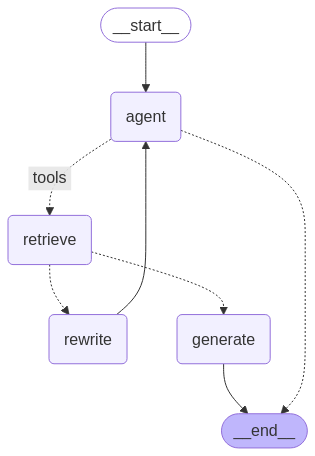

### (1) VectorDB 준비(retriever)

In [8]:
from langchain.document_loaders import CSVLoader

# CSV 파일 로드
path = './langchain/'
csv_path = path + "sample.csv"
csv_loader = CSVLoader(file_path=csv_path)
documents_csv = csv_loader.load()

# 벡터 DB 정의
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = Chroma.from_documents(documents_csv, embedding,
                                    persist_directory="chroma_db")

retriever = vectorstore.as_retriever()

C:\Users\USER\AppData\Local\Temp\ipykernel_14652\2822720714.py:10: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embedding = OpenAIEmbeddings(model="text-embedding-3-small")


In [9]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_blog_posts",    # 함수 이름은 영문, 띄어쓰기 없어야함.
    '''Search and return information about Lilian Weng blog posts on LLM agents,
     prompt engineering, and adversarial attacks on LLMs.''',
)

tools = [retriever_tool]

In [10]:
retriever_tool.invoke("What is the agent?")

'\ufeff구분: 탈옥\n내용: LLM 공격 중 유명한 것에 탈옥(jailbreak)이라는 수법이 있다. 탈옥은 의도적으로 사용자가 제시한 지침을 어기게 하고 멀웨어를 생성하도록 속이는 교묘한 프롬프트를 만드는 것이다. 일부 벤더는 탈옥 현상을 파악해서 알려주고 막는 서비스를 제공하고 있다. 오픈소스 모델에 보내는 메시지에 접근하며 의심스러운 활동의 징후를 모니터링하는 벤더도 있다.\r\n악의적인 공격자가 비공개 환경에서 실행되는 엔터프라이즈 버전의 제품을 구매할 가능성은 낮다. 애초에 프롬프트 정보가 기업 내부에서만 입력되고 벤더에게 전송되지 않기 때문이다.\n\n\ufeff구분: 탈옥\n내용: 반면에 악의적인 공격자는 접근하기 쉬운 오픈소스 모델을 무료로 다운로드하여 자신의 환경에서 실행하며 해킹을 시도할 수 있다. 또한 모델이 사용하는 시스템 프롬프트와 안전 기능까지 다 볼 수 있기 때문에 탈옥을 위한 유리한 고지를 선점할 수 있다. 기업에선 오픈소스 AI 모델 전문 보안 담당자가 없는 경우가 많기 때문에 이런 공격에 취약할 수 있다. 라오는 “예를 들어 공격자는 학습 데이터를 분석하여 모델이 이미지를 잘못 식별하거나 사용자가 인식하지 못하게 문제 없어 보이는 프롬프트를 만드는 방법을 알아낼 수 있다”라고 설명했다.\r\nAI 모델 출력물에 워터마크를 추가해도 공격을 막지 못할 수도 있다. 악의적인 공격자가 코드를 분석 및 리버스 엔지니어링을 통해 워터마크를 제거할 수 있기 때문이다. 또한 공격자는 모델이나 기타 지원 코드 및 도구를 분석하여 취약한 영역을 찾을 수도 있다.\r\n컨설팅 업체인 노탈(Nortal)의 수석 데이터 과학자인 엘레나 수기스는 “공격자는 특정 요청을 계속 보내 인프라를 과부하시켜 모델이 작동하지 않도록 만들 수 있다”라며 “모델이 특정 시스템의 일부이고 모델 출력 결과가 시스템의 다른 부분에서 사용되는 경우 문제가 될 수 있다. 특히 모델의 출력 생성 방식을 공격할 수 있다면 전체 시스템이 중단될 수 있다. 기업에 매우 위험한 

### (2) Agentic RAG 노드 및 엣지 정의

#### 1) Agent의 상태 정의

Agent는 메시지를 상태로 저장하고, 새로운 메시지가 추가될 때마다 업데이트합니다.


In [11]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

- AgentState: 시스템이 다루는 상태 정보를 정의 (메시지 리스트)
- add_messages: 기존 메시지 목록을 유지하면서 새로운 메시지를 추가 (덮어쓰기 X)


#### 2) Agent가 검색할지 여부 결정 (agent)

Agent는 검색이 필요한지 판단하고, 검색 도구를 실행할지 결정합니다.

In [12]:
def agent(state):
    """
    Agent 모델을 실행하여 검색할지 결정합니다.
    """
    print("---Agent 실행---")

    messages = state["messages"]
    model = ChatOpenAI(temperature=0, streaming=True, model="gpt-4.1-mini")

    # 검색 도구를 Agent와 연결
    model = model.bind_tools(tools)

    # Agent 실행
    response = model.invoke(messages)

    # 새로운 응답 메시지를 상태에 추가하여 반환
    return {"messages": [response]}


#### 3) 검색된 문서의 적절성 평가 (grade_documents)

검색된 문서가 질문과 관련이 있는지 판단하는 노드입니다.

In [13]:
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    검색된 문서가 사용자 질문과 관련이 있는지 판단합니다.
    - 관련성이 높으면 'generate' (답변 생성)으로 이동
    - 관련성이 낮으면 'rewrite' (검색어 개선)으로 이동
    """

    print("---검색된 문서의 적절성 평가 수행---")

    # 결과가 yes, no 로만 나오도록 출력 정의
    class grade(BaseModel):
        """검색된 문서의 적절성을 평가하는 이진 점수 (yes 또는 no)"""
        binary_score: str = Field(description="검색된 문서의 적절성 점수 (예: 'yes' 또는 'no')")

    # OpenAI gpt-4.1-mini 모델 설정
    model = ChatOpenAI(temperature=0, model="gpt-4.1-mini", streaming=True)
    llm_with_tool = model.with_structured_output(grade)

    # 프롬프트 템플릿 정의
    prompt = PromptTemplate(
        template="""당신은 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 역할을 수행합니다.
        다음은 검색된 문서입니다: \n\n {context} \n\n
        다음은 사용자 질문입니다: {question} \n
        문서가 질문과 관련된 키워드나 의미를 포함하고 있다면 'yes', 아니라면 'no'를 출력하세요.""",
        input_variables=["context", "question"],
    )

    # 체인 실행
    chain = prompt | llm_with_tool
    messages = state["messages"]
    last_message = messages[-1]  # 최근 메시지 (검색된 문서)
    question = messages[0].content  # 원본 질문

    # 검색된 문서와 질문을 LLM에 입력하여 적절성 평가 수행
    scored_result = chain.invoke({"question": question, "context": last_message.content})
    score = scored_result.binary_score

    # 문서가 적절하면 답변 생성(generate), 그렇지 않으면 검색어 개선(rewrite)
    if score == "yes":
        print("---결정: 문서가 관련 있음 (답변 생성으로 이동)---")
        return "generate"
    else:
        print("---결정: 문서가 관련 없음 (검색어 개선으로 이동)---")
        return "rewrite"


#### 4) 검색어 개선 (rewrite)

검색된 문서가 적절하지 않다면, 검색어를 개선하여 다시 검색합니다.

In [14]:
def rewrite(state):
    """
    검색어를 보다 적절하게 변경하여 검색 성능을 향상시킵니다.
    """
    print("---검색어 개선 수행---")

    messages = state["messages"]
    question = messages[0].content

    # 검색어 개선을 위한 메시지 생성
    msg = [
        HumanMessage(
            content=f"""
    입력된 질문을 보고 의미적으로 더 적절한 표현을 찾아보세요.
    다음은 원본 질문입니다:
    {question}
    더 나은 검색어로 변환하세요:
            """
        )
    ]

    # 검색어 개선 수행
    model = ChatOpenAI(temperature=0, model="gpt-4.1-mini", streaming=True)
    response = model.invoke(msg)

    return {"messages": [response]}


#### 5) 답변 생성 (generate)

In [15]:
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain.prompts import ChatPromptTemplate

def generate(state):
    """
    검색된 문서를 기반으로 답변을 생성합니다.
    """
    print("---답변 생성 시작---")

    messages = state["messages"]
    question = messages[0].content             # 사용자의 질문
    last_message = messages[-1]                # ToolMessage (검색 결과)
    docs = last_message.content                # 검색된 문서 내용 (text)

    # 프롬프트 가져오기
    prompt = ChatPromptTemplate.from_template(
        '''You are an assistant for question-answering tasks.
        Use the following pieces of retrieved context to answer the question.
        If you don't know the answer, just say that you don't know.
        Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:'''
    )
    formatted_prompt = prompt.format(question=question, context = docs)

    llm = ChatOpenAI(model_name="gpt-4.1-mini", temperature=0, streaming=True)


    # RAG 실행 체인
    rag_chain = prompt | llm | StrOutputParser()

    # 최종 답변 생성
    response = rag_chain.invoke(formatted_prompt)

    return {"messages": [AIMessage(content=response)]}


### (3) 그래프 구축 및 실행

In [16]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

# 새로운 상태 그래프 정의
workflow = StateGraph(AgentState)

# 노드 추가
workflow.add_node("agent", agent)
retrieve = ToolNode([retriever_tool])
workflow.add_node("retrieve", retrieve)
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)

# 엣지 추가: Agent → 검색 또는 종료
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", tools_condition, {"tools": "retrieve", END: END})
workflow.add_conditional_edges("retrieve", grade_documents)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# 그래프 컴파일
graph = workflow.compile()


* 시각화

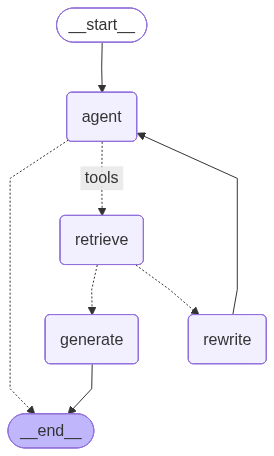

In [17]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

### (4) 실행

In [18]:
import pprint

inputs = {
    "messages": [
        ("user", "What does Lilian Weng say about the types of agent memory?"),
    ]
}
for output in graph.stream(inputs):
    for key, value in output.items():
        pprint.pprint(f"Output from node '{key}':")
        pprint.pprint("---")
        pprint.pprint(value, indent=2, width=80, depth=None)
    pprint.pprint("\n---\n")

---Agent 실행---
"Output from node 'agent':"
'---'
{ 'messages': [ AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_HxY0hQBy9Ry60e3Hjji4eat5', 'function': {'arguments': '{"query":"types of agent memory"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'service_tier': 'default'}, id='run--40a71ce6-b8ec-4cbc-a503-267670b81ea5-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'types of agent memory'}, 'id': 'call_HxY0hQBy9Ry60e3Hjji4eat5', 'type': 'tool_call'}])]}
'\n---\n'
---검색된 문서의 적절성 평가 수행---
---결정: 문서가 관련 없음 (검색어 개선으로 이동)---
"Output from node 'retrieve':"
'---'
{ 'messages': [ ToolMessage(content='\ufeff구분: 낯선 라이선스 약관\n내용: 현재 오픈소스 AI 라이선스 유형은 다양한 만큼 매우 복잡하다. 오픈소스 AI 모델을 이용하려면 상업적으로 사용해도 괜찮은지, 수정 및 배포가 가능한지, 사내 코드 베이스에 안전하게 통합할 수 있는지 등을 알아봐야 한다. 여기에 몇 가지 새로운 문제가 등장했다. 일단 이전에는 볼 수 없는 제약이 오픈소스 라이선스에 적용됐다

In [19]:
result = graph.invoke(inputs)

---Agent 실행---
---검색된 문서의 적절성 평가 수행---
---결정: 문서가 관련 없음 (검색어 개선으로 이동)---
---검색어 개선 수행---
---Agent 실행---
---검색된 문서의 적절성 평가 수행---
---결정: 문서가 관련 없음 (검색어 개선으로 이동)---
---검색어 개선 수행---
---Agent 실행---
---검색된 문서의 적절성 평가 수행---
---결정: 문서가 관련 없음 (검색어 개선으로 이동)---
---검색어 개선 수행---
---Agent 실행---


In [20]:
result['messages']

[HumanMessage(content='What does Lilian Weng say about the types of agent memory?', additional_kwargs={}, response_metadata={}, id='22b5836a-c91a-4135-aa14-a6eb39f86a5e'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_qapsAUmTIiqSSHtGeTVS50w6', 'function': {'arguments': '{"query":"types of agent memory"}', 'name': 'retrieve_blog_posts'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4c2851f862', 'service_tier': 'default'}, id='run--af943649-8adc-4ae3-a512-4b05b3243c60-0', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'types of agent memory'}, 'id': 'call_qapsAUmTIiqSSHtGeTVS50w6', 'type': 'tool_call'}]),
 ToolMessage(content='\ufeff구분: 낯선 라이선스 약관\n내용: 현재 오픈소스 AI 라이선스 유형은 다양한 만큼 매우 복잡하다. 오픈소스 AI 모델을 이용하려면 상업적으로 사용해도 괜찮은지, 수정 및 배포가 가능한지, 사내 코드 베이스에 안전하게 통합할 수 있는지 등을 알아봐야 한다. 여기에 몇 가지 새로운 문제가 등장했다. 일단 이전에는 볼 수 없는 제약이 오픈소스 라이선스에 적용됐다.\r\n메타의 라마(L

In [21]:
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

What does Lilian Weng say about the types of agent memory?
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_qapsAUmTIiqSSHtGeTVS50w6)
 Call ID: call_qapsAUmTIiqSSHtGeTVS50w6
  Args:
    query: types of agent memory
================================= Tool Message =================================
Name: retrieve_blog_posts

﻿구분: 낯선 라이선스 약관
내용: 현재 오픈소스 AI 라이선스 유형은 다양한 만큼 매우 복잡하다. 오픈소스 AI 모델을 이용하려면 상업적으로 사용해도 괜찮은지, 수정 및 배포가 가능한지, 사내 코드 베이스에 안전하게 통합할 수 있는지 등을 알아봐야 한다. 여기에 몇 가지 새로운 문제가 등장했다. 일단 이전에는 볼 수 없는 제약이 오픈소스 라이선스에 적용됐다.
메타의 라마(Llama) 라이선스를 예로 보자. 라마는 높은 인기를 자랑하는 오픈소스 LLM이다. 메타는 라마에 대해 ‘개방형 접근권을 제공하고 잠재적인 오용 문제를 해결하기 맞춤형 상용 라이선스 모델’을 적용한다고 밝혔다. 또한 이에 대해 ‘책임 및 보호 조치의 균형을 맞추기 위한 조치’라고 소개하고 있다.
이런 라이선스 하에 기업은 상업적으로 라마 모델을 사용할 수 있고 개발자는 기본 라마 모델 위에 추가 작업을 만들어 배포할 수 있다. 단 다른 LLM을 개선하기 위해 라마가 출력하는 결과물을 활용할 수는 없다. (라마 파생 모델은 제외된다.) 또한 기업 또는 그